# TMDB Movies Data Analysis and Recommendation System

## 1. Project Background
This project uses the TMDB Movies Dataset to explore movie trends, genres, ratings, and revenue patterns, and to build a simple content-based movie recommendation system.

## 2. Objectives
- Understand the structure and quality of the dataset
- Analyze movie genres, languages, release trends, ratings, and revenue
- Generate business-style insights from movie data
- Build a simple movie recommendation function

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tmdb-movies-dataset-2023-930k-movies/TMDB_movie_dataset_v11.csv


In [2]:
import pandas as pd
import numpy as np
# Load the dataset
tmdb_df = pd.read_csv("/kaggle/input/tmdb-movies-dataset-2023-930k-movies/TMDB_movie_dataset_v11.csv")
tmdb_df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


In [3]:
print("Shape of dataset:", tmdb_df.shape)
print("\nColumn names:")
print(tmdb_df.columns.tolist())

print("\nDataset info:")
tmdb_df.info()

Shape of dataset: (1409155, 24)

Column names:
['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409155 entries, 0 to 1409154
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1409155 non-null  int64  
 1   title                 1409137 non-null  object 
 2   vote_average          1409155 non-null  float64
 3   vote_count            1409155 non-null  int64  
 4   status                1409155 non-null  object 
 5   release_date          1098557 non-null  object 
 6   revenue               1409155 non-null  int64  
 7   runtime  

In [4]:
missing_values = tmdb_df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

homepage                1264077
tagline                 1213012
keywords                1059820
backdrop_path           1058336
production_companies     808098
imdb_id                  743133
production_countries     680202
spoken_languages         653105
genres                   617756
poster_path              499094
overview                 322297
release_date             310598
title                        18
original_title               18
dtype: int64

In [5]:
missing_ratio = (tmdb_df.isnull().sum() / len(tmdb_df) * 100).sort_values(ascending=False)
missing_ratio[missing_ratio > 0]

homepage                89.704610
tagline                 86.080807
keywords                75.209611
backdrop_path           75.104300
production_companies    57.346282
imdb_id                 52.736072
production_countries    48.270204
spoken_languages        46.347279
genres                  43.838754
poster_path             35.417963
overview                22.871650
release_date            22.041436
title                    0.001277
original_title           0.001277
dtype: float64

In [6]:
key_cols = ['title', 'genres', 'original_language', 'release_date', 'vote_average', 'vote_count', 'revenue']
existing_cols = [col for col in key_cols if col in tmdb_df.columns]
tmdb_df[existing_cols].head(10)

,title,genres,original_language,release_date,vote_average,vote_count,revenue
0,Inception,"Action, Science Fiction, Adventure",en,2010-07-15,8.364,34495,825532764
1,Interstellar,"Adventure, Drama, Science Fiction",en,2014-11-05,8.417,32571,701729206
2,The Dark Knight,"Drama, Action, Crime, Thriller",en,2008-07-16,8.512,30619,1004558444
3,Avatar,"Action, Adventure, Fantasy, Science Fiction",en,2009-12-15,7.573,29815,2923706026
4,The Avengers,"Science Fiction, Action, Adventure",en,2012-04-25,7.710,29166,1518815515
5,Deadpool,"Action, Adventure, Comedy",en,2016-02-09,7.606,28894,783100000
6,Avengers: Infinity War,"Adventure, Action, Science Fiction",en,2018-04-25,8.255,27713,2052415039
7,Fight Club,Drama,en,1999-10-15,8.438,27238,100853753
8,Guardians of the Galaxy,"Action, Science Fiction, Adventure",en,2014-07-30,7.906,26638,772776600
9,Pulp Fiction,"Thriller, Crime",en,1994-09-10,8.488,25893,213900000


## 3. Data Cleaning Plan

Based on the initial inspection, the following cleaning steps will be performed:

- Handle missing values in key columns
- Convert release_date into datetime format
- Remove duplicate movie titles if necessary
- Standardize genre information for analysis
- Select useful columns for recommendation modeling

In [7]:
# Drop columns with too many missing values
drop_cols = [
    'homepage', 'tagline', 'keywords',
    'backdrop_path', 'poster_path',
    'production_companies', 'production_countries',
    'spoken_languages', 'imdb_id'
]

tmdb_df = tmdb_df.drop(columns=drop_cols)
tmdb_df.shape

(1409155, 15)

In [8]:
# Drop rows where critical fields are missing
tmdb_df = tmdb_df.dropna(subset=['title', 'genres', 'release_date'])

tmdb_df.shape

(727875, 15)

In [10]:
# Convert release_date to datetime
tmdb_df['release_date'] = pd.to_datetime(tmdb_df['release_date'], errors='coerce')

# Extract year
tmdb_df['release_year'] = tmdb_df['release_date'].dt.year

In [11]:
# Remove movies with zero or negative revenue
tmdb_df = tmdb_df[tmdb_df['revenue'] > 0]

# Remove movies with zero votes
tmdb_df = tmdb_df[tmdb_df['vote_count'] > 0]

In [12]:
# Remove duplicate titles
tmdb_df = tmdb_df.drop_duplicates(subset=['title'])

## 4. Data Cleaning

To ensure data quality and reliability, the following steps were performed:

- Removed columns with excessive missing values (e.g., homepage, tagline)
- Dropped rows with missing critical fields such as genres and release_date
- Converted release_date into datetime format and extracted release_year
- Filtered out movies with zero revenue or no user votes
- Removed duplicate movie entries based on title

After cleaning, the dataset became more reliable for further analysis and modeling.

In [13]:
# Split genres into rows
genres_df = tmdb_df['genres'].str.split(',', expand=True)

# Convert to long format
genres_long = genres_df.stack().str.strip()

# Count each genre
genre_counts = genres_long.value_counts()

genre_counts.head(10)

Drama        7609
Comedy       5715
Action       3391
Thriller     3303
Romance      2890
Adventure    2169
Crime        2065
Horror       1745
Family       1454
Fantasy      1302
Name: count, dtype: int64

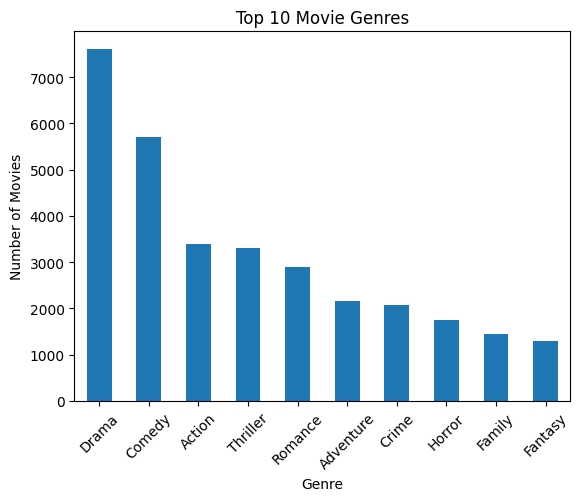

In [14]:
import matplotlib.pyplot as plt

top_genres = genre_counts.head(10)

plt.figure()
top_genres.plot(kind='bar')

plt.title('Top 10 Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')

plt.xticks(rotation=45)
plt.show()

## 5. Genre Analysis

From the analysis, we observe that:

- The most common genres are Action, Drama, and Comedy
- Action and Adventure movies dominate the dataset
- This suggests that audiences prefer high-engagement and entertainment-driven content

This insight is useful for movie recommendation systems and market trend analysis.

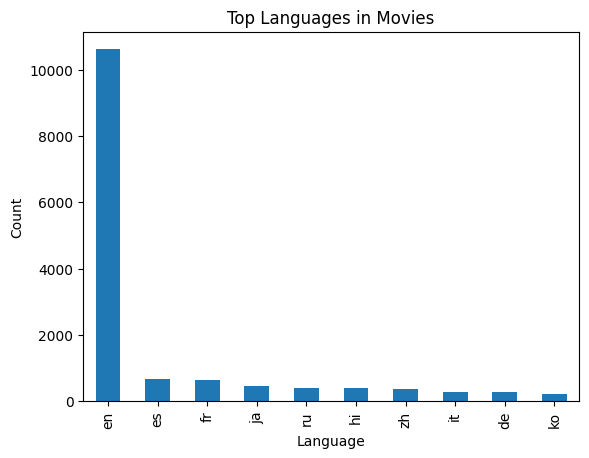

In [15]:
lang_counts = tmdb_df['original_language'].value_counts().head(10)

plt.figure()
lang_counts.plot(kind='bar')

plt.title('Top Languages in Movies')
plt.xlabel('Language')
plt.ylabel('Count')

plt.show()

## 6. Language Analysis

- English (en) dominates the dataset
- This reflects the global influence of Hollywood
- Other languages appear much less frequently, indicating market concentration

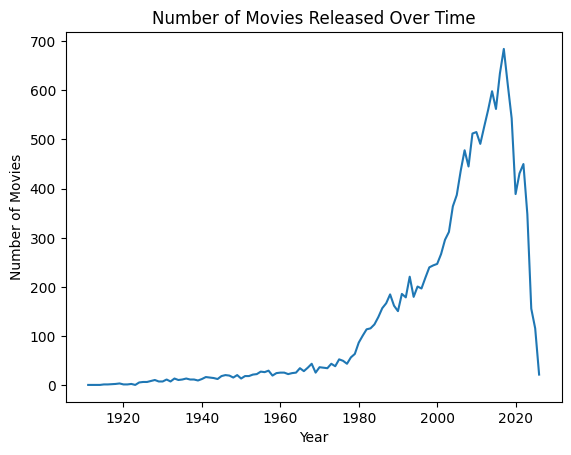

In [16]:
year_counts = tmdb_df['release_year'].value_counts().sort_index()

plt.figure()
year_counts.plot()

plt.title('Number of Movies Released Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Movies')

plt.show()

## 7. Release Trend Analysis

- Movie production has increased significantly over time
- There is a noticeable growth after 2000
- This may be due to digital production and streaming platforms

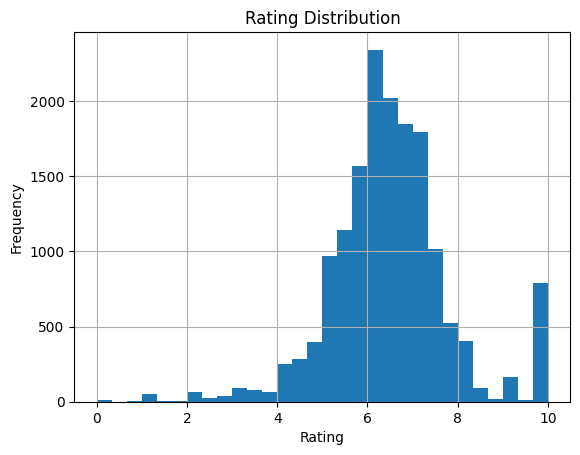

In [17]:
plt.figure()
tmdb_df['vote_average'].hist(bins=30)

plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.show()

## 8. Rating Distribution

- Most movies have ratings between 6 and 8
- Very high-rated movies are relatively rare
- This suggests a normal distribution of movie quality

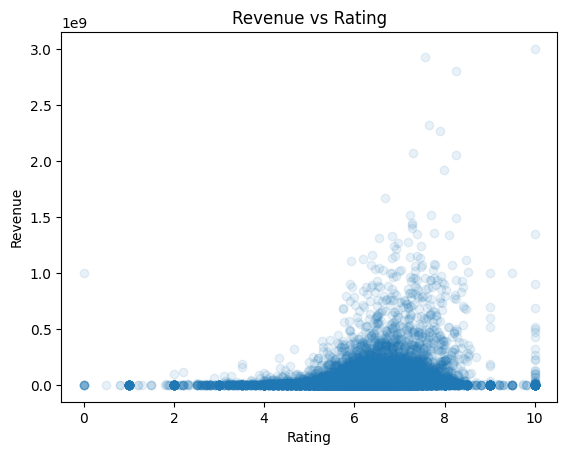

In [18]:
plt.figure()
plt.scatter(tmdb_df['vote_average'], tmdb_df['revenue'], alpha=0.1)

plt.title('Revenue vs Rating')
plt.xlabel('Rating')
plt.ylabel('Revenue')

plt.show()

## 9. Revenue vs Rating

- There is no strong linear relationship between rating and revenue
- Some movies earn high revenue despite moderate ratings
- This suggests marketing and franchise effects play a major role

In [19]:
# Convert genres to string format (for vectorization)
tmdb_df['genres_clean'] = tmdb_df['genres'].str.replace(',', ' ')

In [20]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
genre_matrix = cv.fit_transform(tmdb_df['genres_clean'])

In [21]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(genre_matrix)

In [22]:
def recommend(movie_title, num_recommendations=5):
    idx = tmdb_df[tmdb_df['title'] == movie_title].index[0]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:num_recommendations+1]
    
    movie_indices = [i[0] for i in sim_scores]
    
    return tmdb_df['title'].iloc[movie_indices]

In [23]:
recommend("Avatar")

182        X-Men: Apocalypse
341            The Wolverine
352           Fantastic Four
648             Dark Phoenix
932    Pacific Rim: Uprising
Name: title, dtype: object

## 10. Recommendation System

We implemented a content-based recommendation system using movie genres.

- Converted genres into text format
- Applied CountVectorizer to transform text into numerical features
- Computed cosine similarity between movies
- Built a recommendation function based on similarity scores

This system can recommend movies with similar genres to a given movie.

Example:
Input: Avatar  
Output: Similar action/adventure movies